<a href="https://colab.research.google.com/github/Gameloque/checkpoint_ML_SERS_1CCA/blob/main/AULA_07_SERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 2 – Regressão Linear e Estabilidade da Rede Elétrica

Esta atividade faz parte do **Checkpoint 2**. O objetivo é construir e comparar dois modelos de Regressão Linear para prever o valor numérico da coluna `stab`, relacionada à estabilidade da rede elétrica.

Ao finalizar, salve este notebook no formato `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Mantenha todas as células executadas, os resultados visíveis e as respostas preenchidas.

## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para manipulação e visualização dos dados, separação entre treino e teste, criação do modelo de Regressão Linear e cálculo das métricas R², MAE e MSE.

In [2]:
# Importe aqui as bibliotecas necessárias
# Preparação do ambiente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Algoritmo de regressão -----> Regressão Linear
from sklearn.linear_model import LinearRegression
# Separação dos dados para treinamento e para teste (train-test-split)
from sklearn.model_selection import train_test_split
# Métricas de avaliação
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2. Carregamento e análise inicial do dataset

Carregue o arquivo CSV do conjunto **Electrical Grid Stability** em um DataFrame chamado `df`. Depois:

- visualize as primeiras linhas;
- verifique a quantidade de linhas e colunas;
- apresente os nomes e os tipos das colunas;
- verifique se existem valores ausentes;
- apresente as estatísticas descritivas das variáveis numéricas.

In [3]:
# Carregue o dataset e realize a análise inicial
dados = pd.read_csv('https://raw.githubusercontent.com/Gameloque/Aulas-SERS/refs/heads/main/Datasets/EletricalStab.csv')
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


### Registro da análise inicial

**Quantidade de linhas:**  
**Quantidade de colunas:**  
**Existem valores ausentes?**  
**Observações importantes sobre o dataset:**  

In [4]:
print(f" Quantidade de Linhas e Colunas:", dados.shape)

 Quantidade de Linhas e Colunas: (10000, 14)


In [5]:
print(f" Análise das Colunas:")
dados.columns

 Análise das Colunas:


Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')

In [6]:
print(f" Dados ausentes:")
dados.isnull().sum()

 Dados ausentes:


,0
tau1,0
tau2,0
tau3,0
tau4,0
p1,0
p2,0
p3,0
p4,0
g1,0
g2,0


In [7]:
print(f"\nAnálise das estátisticas:")
dados.describe()


Análise das estátisticas:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


## 3. Definição da variável target

A variável que os modelos deverão prever é a coluna `stab`. Crie a variável `y` com essa coluna e apresente seus primeiros valores.

In [8]:
# Crie a variável y usando a coluna stab
y = dados["stab"]
display(y.head())

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## 4. Matriz de correlação

Calcule a matriz de correlação das variáveis numéricas e crie um mapa de calor (*heatmap*). Em seguida, identifique as **cinco variáveis com maior correlação absoluta com `stab`**, sem considerar a própria coluna `stab`.

Considere também correlações negativas: quanto mais próximo de +1 ou -1, maior é a intensidade da relação linear.

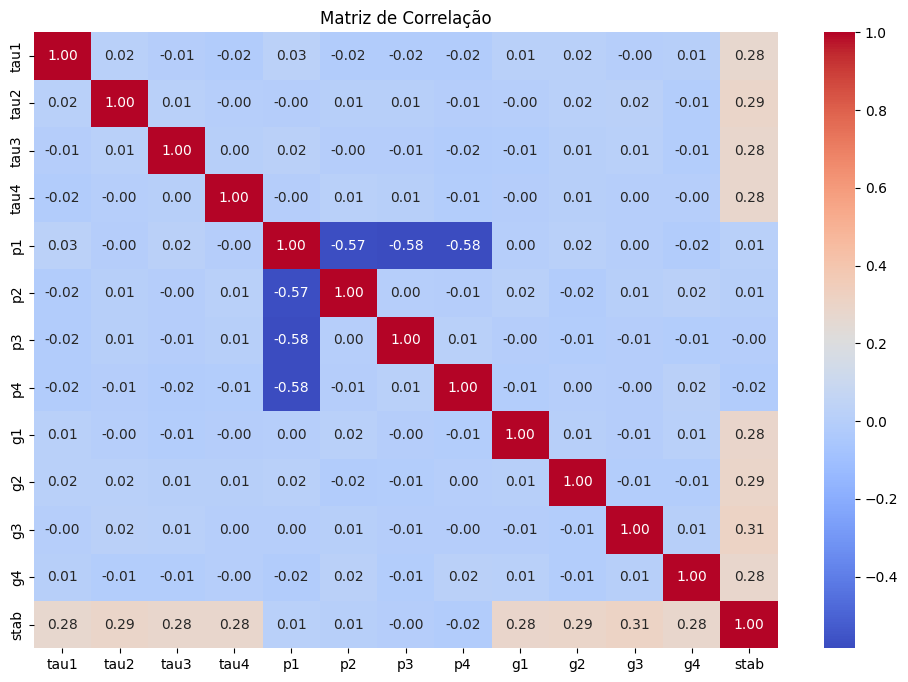

Os maiores cinco valores com correlações absolutas com o stab:


,Correlação
g3,0.308235
g2,0.293601
tau2,0.290975
g1,0.282774
tau3,0.280700


In [9]:
# Calcule e visualize a matriz de correlação
correlacao = dados.select_dtypes(include=np.number).corr()
plt.figure(figsize=(12,8))
sns.heatmap(correlacao, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

correlacoes_stab = correlacao["stab"].drop("stab")
cinco_maiores = correlacoes_stab.abs().sort_values(ascending=False).head(5)
print("Os maiores cinco valores com correlações absolutas com o stab:")
display(correlacoes_stab.loc[cinco_maiores.index].to_frame("Correlação"))

Agora, vamos visualizar os gráficos de dispersão para cada uma das cinco variáveis selecionadas em relação a `stab`.

Variáveis Selecionadas:
['g3', 'g2', 'tau2', 'g1', 'tau3']
Correlações:
g3: 0.308235
g2: 0.293601
tau2: 0.290975
g1: 0.282774
tau3: 0.280700


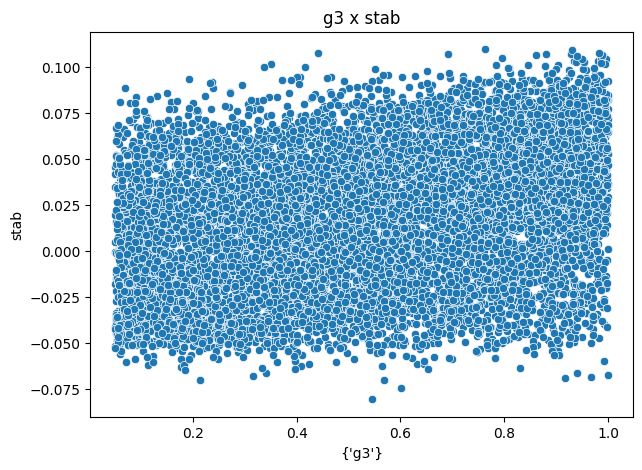

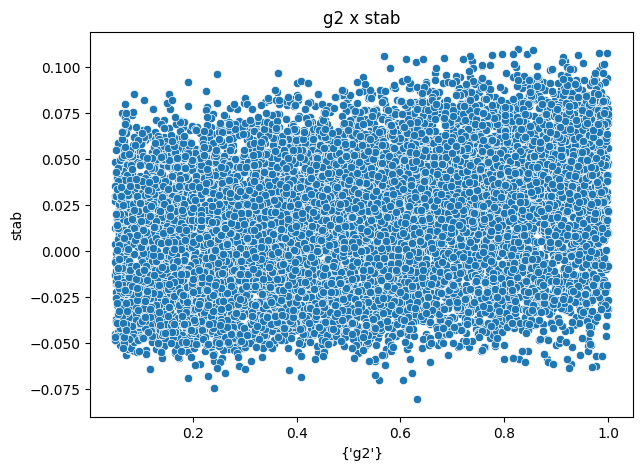

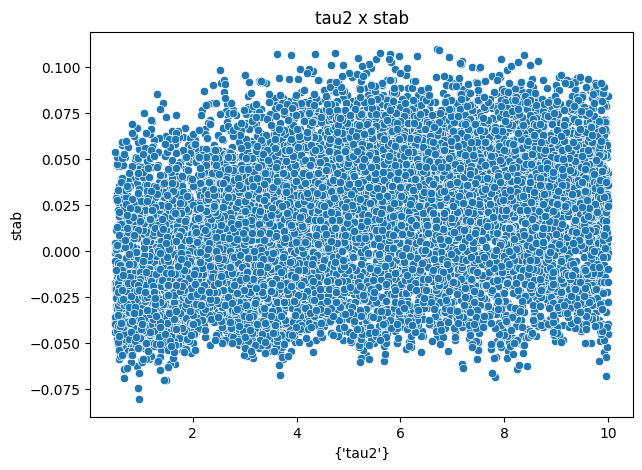

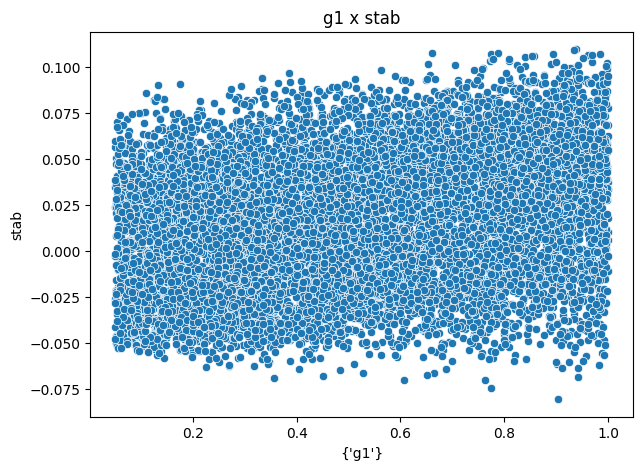

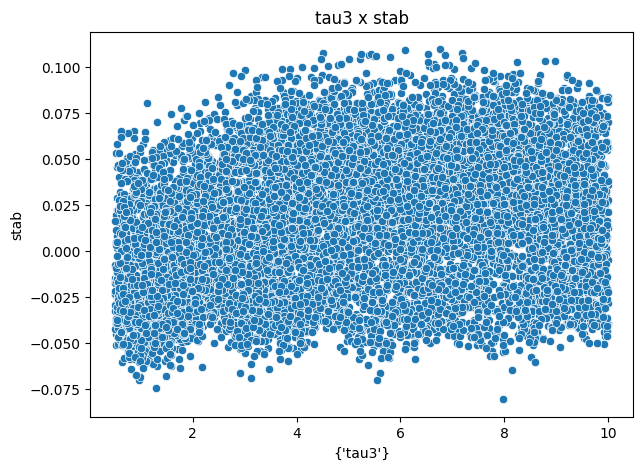

In [10]:
cinco_variaveis = cinco_maiores.index.tolist()
print("Variáveis Selecionadas:")
print(cinco_variaveis)

print("Correlações:")
for variavel in cinco_variaveis:
  print(f"{variavel}: {correlacoes_stab[variavel]:.6f}")
for variavel in cinco_variaveis:
  plt.figure(figsize=(7,5))
  sns.scatterplot(data=dados, x=variavel, y="stab")
  plt.title(f"{variavel} x stab")
  plt.xlabel({variavel})
  plt.ylabel("stab")
  plt.show()

## 5. Apoio do Gemini para seleção e visualização das variáveis

Depois de criar a matriz de correlação, use o Gemini no Google Colab com o prompt abaixo. Analise o código sugerido antes de executá-lo e faça os ajustes necessários.

> Tenho um DataFrame Pandas chamado `df` com dados do Electrical Grid Stability. A variável target é a coluna `stab`. Gere um código Python que: (1) calcule a correlação das variáveis numéricas com `stab`; (2) desconsidere a própria coluna `stab`; (3) use o valor absoluto das correlações para identificar as cinco variáveis com maior correlação com `stab`; (4) apresente os nomes das cinco variáveis e os valores originais de correlação, preservando os sinais positivo ou negativo; (5) armazene os nomes dessas variáveis em uma lista chamada `cinco_variaveis`; e (6) crie cinco gráficos de dispersão, um para cada variável selecionada, usando a variável no eixo X e `stab` no eixo Y. Utilize Pandas, Matplotlib e Seaborn. O DataFrame `df` já está carregado.

In [11]:
# Cole, revise e execute aqui o código gerado com o apoio do Gemini


### Variáveis selecionadas

| Posição | Variável | Correlação original com `stab` |
|---:|---|---:|
| 1 |   g3 | 0.308235 |
| 2 |  g2  | 0.293601 |
| 3 | tau2 | 0.290975 |
| 4 | g1   | 0.282774 |
| 5 | tau3 | 0.280700 |

**Qual variável apresentou a maior correlação absoluta com `stab`?**  
Resposta:  A variável "g3".

**O que os gráficos de dispersão indicam sobre as relações entre essas variáveis e `stab`?**  
Resposta:  

# Modelo 1 – Cinco maiores correlações

Crie o DataFrame `X` utilizando somente as cinco variáveis selecionadas a partir da matriz de correlação. A variável `y` deve continuar sendo a coluna `stab`.

In [12]:
# Crie X com as cinco variáveis selecionadas
X = dados[cinco_variaveis]

# Mostre as primeiras linhas de X e y
print("X:")
display(X.head())
print()
print("y:")
display(y.head())

X:


,g3,g2,tau2,g1,tau3
0,0.887445,0.859578,3.079885,0.650456,8.381025
1,0.562139,0.862414,4.902524,0.413441,3.047541
2,0.839444,0.766689,8.848428,0.163041,3.046479
3,0.929381,0.976744,7.669600,0.446209,4.486641
4,0.656947,0.455450,7.608772,0.797110,4.943759



y:


,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## 6. Separação entre treino e teste

Separe `X` e `y` utilizando 80% dos dados para treinamento e 20% para teste, com `random_state=42`. Use os nomes `X_treino`, `X_teste`, `y_treino` e `y_teste`. Apresente a quantidade de registros em cada conjunto.

In [13]:
# Separe os dados de treino e teste do Modelo 1
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.20, random_state=42)

print("Registro de treino:", len(X_treino))
print("Registro de teste:", len(X_teste))


Registro de treino: 8000
Registro de teste: 2000


## 7. Treinamento e previsões do Modelo 1

Crie um modelo de Regressão Linear chamado obrigatoriamente `modeloLR`. Treine o modelo e gere as previsões do conjunto de teste em uma variável chamada `y_previsao_1`.

In [14]:
# Crie e treine modeloLR
modeloLR = LinearRegression()
modeloLR.fit(X_treino, y_treino)

# Gere y_previsao_1
y_previsao_1 = modeloLR.predict(X_teste)

print("Modelo 1 treinado.")

Modelo 1 treinado.


## 8. Métricas do Modelo 1

Calcule R², MAE e MSE. Armazene os resultados nas variáveis `r2_modelo_1`, `mae_modelo_1` e `mse_modelo_1`. Esses valores serão usados na comparação final.

In [15]:
# Calcule e apresente as três métricas do Modelo 1
r2_modelo_1 = r2_score(y_teste, y_previsao_1)
mae_modelo_1 = mean_absolute_error(y_teste, y_previsao_1)
mse_modelo_1 = mean_squared_error(y_teste, y_previsao_1)

print(f"R²  = {r2_modelo_1:.6f}")
print(f"MAE = {mae_modelo_1:.6f}")
print(f"MSE = {mse_modelo_1:.6f}")

R²  = 0.401770
MAE = 0.023310
MSE = 0.000811


# Modelo 2 – Variáveis `tau` e `g`

Crie um novo DataFrame chamado `X_tau_g` contendo todas as colunas cujos nomes começam com `tau` ou `g`. Liste as colunas selecionadas para conferir o resultado. A variável target permanece `y = df['stab']`.

In [16]:
# Selecione todas as colunas iniciadas por tau ou g
# X_tau_g = ...

# Liste as colunas selecionadas
colunas_tau_g = [
    coluna for coluna in dados.columns
    if coluna.startswith("tau") or coluna.startswith("g")
]

X_tau_g = dados[colunas_tau_g]

print("Colunas selecionadas:")
print(X_tau_g.columns.tolist())
display(X_tau_g.head())

Colunas selecionadas:
['tau1', 'tau2', 'tau3', 'tau4', 'g1', 'g2', 'g3', 'g4']


,tau1,tau2,tau3,tau4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,0.797110,0.455450,0.656947,0.820923


## 9. Separação entre treino e teste do Modelo 2

Separe `X_tau_g` e `y` usando novamente 80% para treino, 20% para teste e `random_state=42`. Use os nomes `X2_treino`, `X2_teste`, `y2_treino` e `y2_teste`.

Manter o mesmo `random_state` e a mesma proporção é importante para comparar os modelos sobre os mesmos registros de teste.

In [17]:
# Separe os dados de treino e teste do Modelo 2
X2_treino, X2_teste, y2_treino, y2_teste = train_test_split(X_tau_g, y, test_size=0.20, random_state=42)
# Confirme se y_teste e y2_teste possuem os mesmos índices
print("Registros de treino:", len(X2_treino))
print("Registros de teste:", len(X2_teste))
print("Os testes possuem os mesmos índices?",
      y_teste.index.equals(y2_teste.index))

Registros de treino: 8000
Registros de teste: 2000
Os testes possuem os mesmos índices? True


## 10. Treinamento, previsões e métricas do Modelo 2

Crie um segundo modelo de Regressão Linear chamado `modeloLR_tau_g`. Treine-o, gere as previsões em `y_previsao_2` e armazene as métricas em `r2_modelo_2`, `mae_modelo_2` e `mse_modelo_2`.

In [18]:
# Crie e treine modeloLR_tau_g
modeloLR_tau_g = LinearRegression()
modeloLR_tau_g.fit(X2_treino, y2_treino)
# Gere y_previsao_2
y_previsao_2 = modeloLR_tau_g.predict(X2_teste)
# Calcule e apresente as três métricas do Modelo 2
r2_modelo_2 = r2_score(y2_teste, y_previsao_2)
mae_modelo_2 = mean_absolute_error(y2_teste, y_previsao_2)
mse_modelo_2 = mean_squared_error(y2_teste, y_previsao_2)

print(f"R²  = {r2_modelo_2:.6f}")
print(f"MAE = {mae_modelo_2:.6f}")
print(f"MSE = {mse_modelo_2:.6f}")

R²  = 0.645229
MAE = 0.017553
MSE = 0.000481


# Comparação das métricas dos dois modelos

As métricas devem ser analisadas **comparativamente**. Crie um único DataFrame chamado `comparacao_modelos` com uma linha para cada modelo e as colunas `Modelo`, `Variáveis utilizadas`, `R²`, `MAE` e `MSE`.

Na comparação:

- um **R² maior** indica que o modelo explica uma parcela maior da variação de `stab`;
- um **MAE menor** indica menor erro absoluto médio;
- um **MSE menor** indica menor erro quadrático médio e penaliza mais intensamente os erros maiores.

Não interprete as métricas de forma isolada: compare os valores obtidos pelos dois modelos.

In [19]:
# Crie e exiba o DataFrame comparacao_modelos
comparacao_modelos = pd.DataFrame({
    "Modelo": ["Modelo 1", "Modelo 2"],
    "Variáveis utilizadas": [
        "5 maiores correlações absolutas",
        "Todas as variáveis tau e g"
    ],
    "R²": [r2_modelo_1, r2_modelo_2],
    "MAE": [mae_modelo_1, mae_modelo_2],
    "MSE": [mse_modelo_1, mse_modelo_2]
})

display(comparacao_modelos)

,Modelo,Variáveis utilizadas,R²,MAE,MSE
0,Modelo 1,5 maiores correlações absolutas,0.401770,0.023310,0.000811
1,Modelo 2,Todas as variáveis tau e g,0.645229,0.017553,0.000481


## Visualização comparativa

Crie três gráficos de barras lado a lado ou em uma mesma figura:

1. R² dos dois modelos;
2. MAE dos dois modelos;
3. MSE dos dois modelos.

Identifique os modelos e as métricas com títulos e rótulos claros.

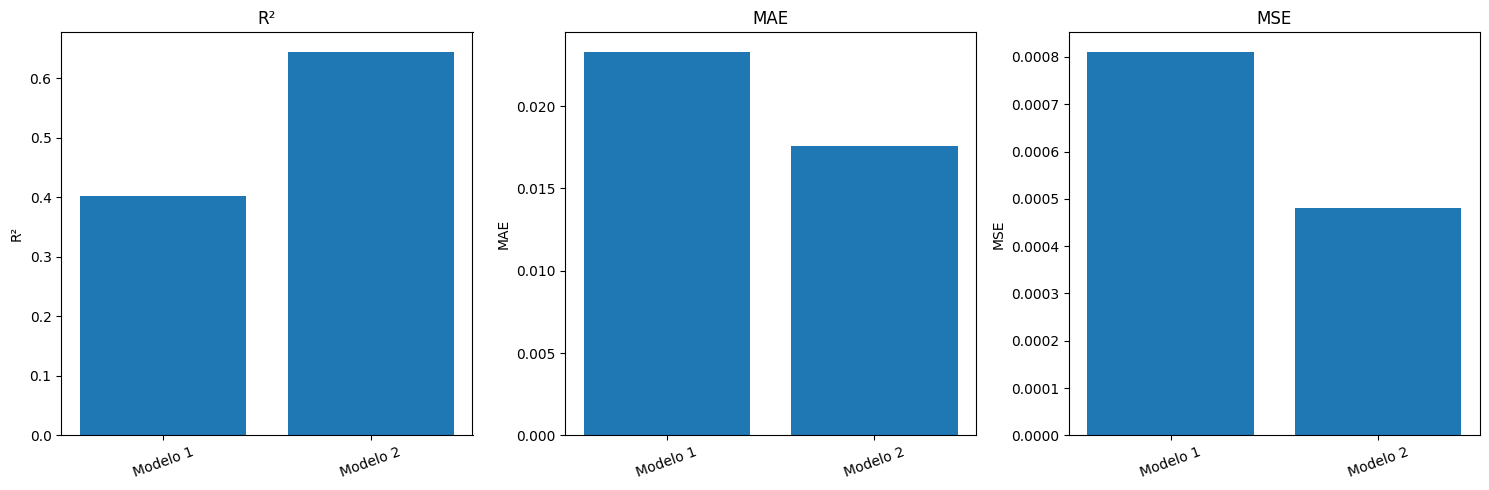

In [20]:
# Crie os gráficos comparativos das métricas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metricas = ["R²", "MAE", "MSE"]

for i, metrica in enumerate(metricas):
    axes[i].bar(comparacao_modelos["Modelo"], comparacao_modelos[metrica])
    axes[i].set_title(metrica)
    axes[i].set_ylabel(metrica)
    axes[i].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Análise comparativa final

Responda com base na tabela e nos gráficos comparativos.

**1. Qual modelo apresentou o maior R²? Informe os valores dos dois modelos.**  
Resposta:  
1. Maior R²:
Modelo 2

| Modelo 1: 0.401770 | Modelo 2: 0.645229

**2. Qual modelo apresentou o menor MAE? Informe os valores dos dois modelos.**  
Resposta:  
2. Menor MAE:
Modelo 2

| Modelo 1: 0.023310 | Modelo 2: 0.017553

**3. Qual modelo apresentou o menor MSE? Informe os valores dos dois modelos.**  
Resposta:  
3. Menor MSE:
Modelo 2

| Modelo 1: 0.000811 | Modelo 2: 0.000481


**4. As três métricas indicaram o mesmo modelo como o de melhor desempenho? Justifique comparando os resultados.**  
Resposta:  
4. As três métricas indicaram o mesmo modelo?
Sim.

**5. O que mudou no desempenho quando as cinco variáveis de maior correlação foram substituídas pelo conjunto completo de variáveis `tau` e `g`?**  
Resposta:  
5. Variações do Modelo 1 para o Modelo 2:

R²:  +0.243459
MAE: -0.005757
MSE: -0.000330

**6. Considerando os resultados obtidos, qual modelo você escolheria para prever `stab`? Justifique com R², MAE e MSE.**  
Resposta:  
6. Resultado da comparação:

As três métricas apontam para Modelo 2.

In [21]:
modelo_maior_r2 = "Modelo 1" if r2_modelo_1 > r2_modelo_2 else "Modelo 2"
modelo_menor_mae = "Modelo 1" if mae_modelo_1 < mae_modelo_2 else "Modelo 2"
modelo_menor_mse = "Modelo 1" if mse_modelo_1 < mse_modelo_2 else "Modelo 2"

print("1. Maior R²:")
print(f"{modelo_maior_r2} | Modelo 1: {r2_modelo_1:.6f} | Modelo 2: {r2_modelo_2:.6f}")

print("\n2. Menor MAE:")
print(f"{modelo_menor_mae} | Modelo 1: {mae_modelo_1:.6f} | Modelo 2: {mae_modelo_2:.6f}")

print("\n3. Menor MSE:")
print(f"{modelo_menor_mse} | Modelo 1: {mse_modelo_1:.6f} | Modelo 2: {mse_modelo_2:.6f}")

print("\n4. As três métricas indicaram o mesmo modelo?")
print("Sim." if modelo_maior_r2 == modelo_menor_mae == modelo_menor_mse else "Não.")

print("\n5. Variações do Modelo 1 para o Modelo 2:")
print(f"R²:  {r2_modelo_2 - r2_modelo_1:+.6f}")
print(f"MAE: {mae_modelo_2 - mae_modelo_1:+.6f}")
print(f"MSE: {mse_modelo_2 - mse_modelo_1:+.6f}")

print("\n6. Resultado da comparação:")
if modelo_maior_r2 == modelo_menor_mae == modelo_menor_mse:
    print(f"As três métricas apontam para {modelo_maior_r2}.")
else:
    print("As métricas não apontam todas para o mesmo modelo; analise os valores da tabela.")

1. Maior R²:
Modelo 2 | Modelo 1: 0.401770 | Modelo 2: 0.645229

2. Menor MAE:
Modelo 2 | Modelo 1: 0.023310 | Modelo 2: 0.017553

3. Menor MSE:
Modelo 2 | Modelo 1: 0.000811 | Modelo 2: 0.000481

4. As três métricas indicaram o mesmo modelo?
Sim.

5. Variações do Modelo 1 para o Modelo 2:
R²:  +0.243459
MAE: -0.005757
MSE: -0.000330

6. Resultado da comparação:
As três métricas apontam para Modelo 2.


# Conferência e entrega

Antes de entregar, verifique se o notebook contém:

- identificação dos integrantes;
- carregamento e análise inicial do dataset;
- `y` definido com a coluna `stab`;
- matriz de correlação e mapa de calor;
- seleção das cinco maiores correlações absolutas;
- cinco gráficos de dispersão em relação a `stab`;
- Modelo 1 com as cinco variáveis selecionadas;
- Modelo 2 com todas as variáveis `tau` e `g`;
- R², MAE e MSE dos dois modelos;
- tabela e gráficos comparativos das métricas;
- respostas da análise comparativa final;
- todas as células executadas e sem erros.

Salve o arquivo `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Este notebook fará parte do **Checkpoint 2**.